In [11]:
import wrds
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

db = wrds.Connection(wrds_username='jinzichun')

Loading library list...
Done


In [2]:
#Fetch financial data from five companies
tickers = "('WMT', 'TGT', 'COST', 'KR', 'DLTR')"
start_year = 2020
end_year = 2025

sql_query = f"""
SELECT 
    tic,
    fyear,
    sale,
    cogs,
    ni,
    at,
    invt,
    teq
FROM comp.funda
WHERE tic IN {tickers}
    AND fyear BETWEEN {start_year} AND {end_year}
    AND indfmt = 'INDL'
    AND datafmt = 'STD'
    AND popsrc = 'D'
    AND consol = 'C'
ORDER BY tic, fyear
"""

data = db.raw_sql(sql_query)

print("First 5 rows:")
print(data.head())
print(f"\nShape: {data.shape}")
print("\nCompanies and years:")
print(data.groupby('tic')['fyear'].value_counts().sort_index())

# Save raw data
data.to_csv('five_retailers_raw.csv', index=False)
print("\nRaw data saved to five_retailers_raw.csv")

First 5 rows:
    tic  fyear      sale      cogs      ni       at     invt      teq
0  COST   2020  166761.0  143186.0  4002.0  55556.0  12242.0  18705.0
1  COST   2021  195929.0  168903.0  5007.0  59268.0  14215.0  18078.0
2  COST   2022  226954.0  197482.0  5844.0  64166.0  17907.0  20647.0
3  COST   2023  242290.0  210509.0  6292.0  68994.0  16651.0  25058.0
4  COST   2024  254453.0  220121.0  7367.0  69831.0  18647.0  23622.0

Shape: (30, 8)

Companies and years:
tic   fyear
COST  2020     1
      2021     1
      2022     1
      2023     1
      2024     1
      2025     1
DLTR  2020     1
      2021     1
      2022     1
      2023     1
      2024     1
      2025     1
KR    2020     1
      2021     1
      2022     1
      2023     1
      2024     1
      2025     1
TGT   2020     1
      2021     1
      2022     1
      2023     1
      2024     1
      2025     1
WMT   2020     1
      2021     1
      2022     1
      2023     1
      2024     1
      2025     1
Name: 

In [3]:
#Calculate financial ratios
df = data.copy()

df['gross_margin'] = (df['sale'] - df['cogs']) / df['sale']
df['net_margin'] = df['ni'] / df['sale']
df['roa'] = df['ni'] / df['at']
df['roe'] = df['ni'] / df['teq']
df['inventory_turnover'] = df['cogs'] / df['invt']

print("Calculated ratios:")
print(df[['tic', 'fyear', 'gross_margin', 'net_margin', 'roa', 'roe', 'inventory_turnover']])

df.to_csv('five_retailers_ratios.csv', index=False)
print("\nRatios saved to five_retailers_ratios.csv")

Calculated ratios:
     tic  fyear  gross_margin  net_margin       roa       roe  \
0   COST   2020       0.14137    0.023998  0.072035  0.213953   
1   COST   2021      0.137938    0.025555  0.084481  0.276966   
2   COST   2022      0.129859     0.02575  0.091076  0.283044   
3   COST   2023      0.131169    0.025969  0.091196  0.251097   
4   COST   2024      0.134925    0.028952  0.105498   0.31187   
5   COST   2025      0.137246    0.029426  0.105047  0.277705   
6   DLTR   2020      0.331883    0.052604  0.064839  0.184193   
7   DLTR   2021      0.321118     0.05045  0.061132  0.172041   
8   DLTR   2022      0.341413    0.057017  0.070167  0.184585   
9   DLTR   2023       0.33522   -0.032623 -0.045333 -0.136522   
10  DLTR   2024      0.387928   -0.172375 -0.162524 -0.761829   
11  DLTR   2025      0.397233    0.066068  0.095238  0.341554   
12    KR   2020      0.233219     0.01951  0.053122  0.270681   
13    KR   2021      0.220099    0.012002  0.033716  0.175522   
14    

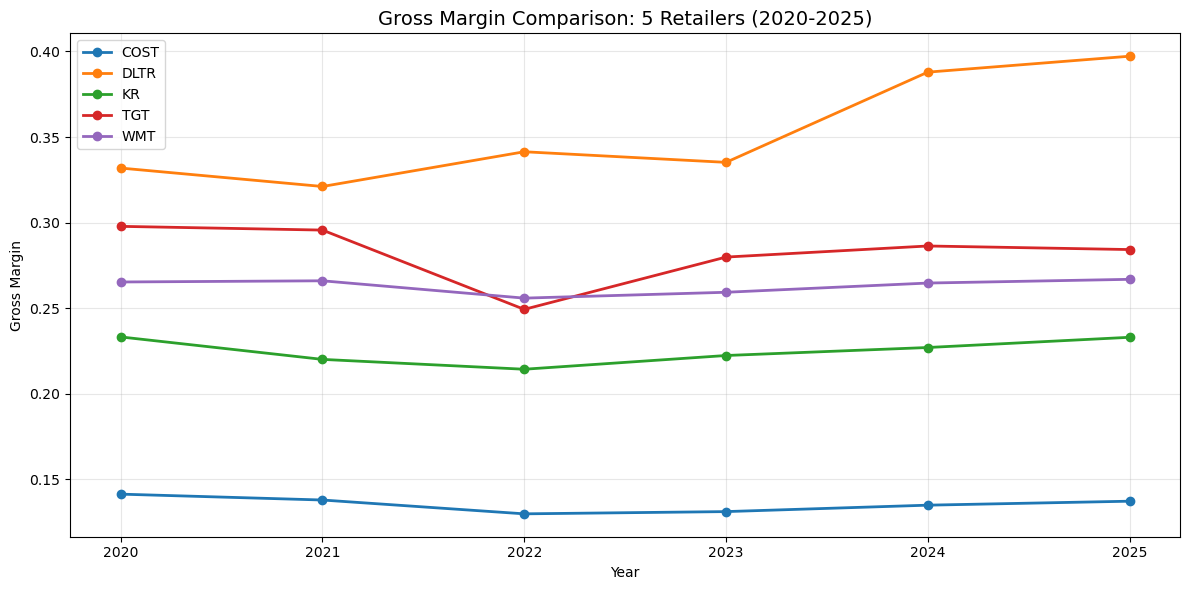

In [7]:
#Multi company gross profit margin line chart
plt.figure(figsize=(12, 6))

for company in df['tic'].unique():
    company_data = df[df['tic'] == company]
    plt.plot(company_data['fyear'], company_data['gross_margin'], 
             'o-', linewidth=2, markersize=6, label=company)

plt.title('Gross Margin Comparison: 5 Retailers (2020-2025)', fontsize=14)
plt.xlabel('Year')
plt.ylabel('Gross Margin')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('gross_margin_comparison.png', dpi=150)
plt.show()

In [4]:
#Retrieve monthly stock data from five companies (2020-2025)
ticker_list = "('WMT', 'TGT', 'COST', 'KR', 'DLTR')"
start_date_stock = "2020-01-01"
end_date_stock = "2025-12-31"

sql_stock = f"""
SELECT 
    a.permno,
    a.date,
    a.ret,
    a.prc,
    b.htsymbol as ticker
FROM crsp.msf a
LEFT JOIN crsp.msfhdr b ON a.permno = b.permno
WHERE b.htsymbol IN {ticker_list}
    AND a.date BETWEEN '{start_date_stock}' AND '{end_date_stock}'
ORDER BY b.htsymbol, a.date
"""

stock_data = db.raw_sql(sql_stock)

print("First 5 rows:")
print(stock_data.head())
print(f"\nShape: {stock_data.shape}")
print(f"Date range: {stock_data['date'].min()} to {stock_data['date'].max()}")

First 5 rows:
   permno        date       ret        prc ticker
0   87055  2020-01-31  0.039466  305.51999   COST
1   87055  2020-02-28 -0.077671  281.14001   COST
2   87055  2020-03-31  0.014192     285.13   COST
3   87055  2020-04-30  0.065128      303.0   COST
4   87055  2020-05-29  0.018053     308.47   COST

Shape: (300, 5)
Date range: 2020-01-31 to 2024-12-31


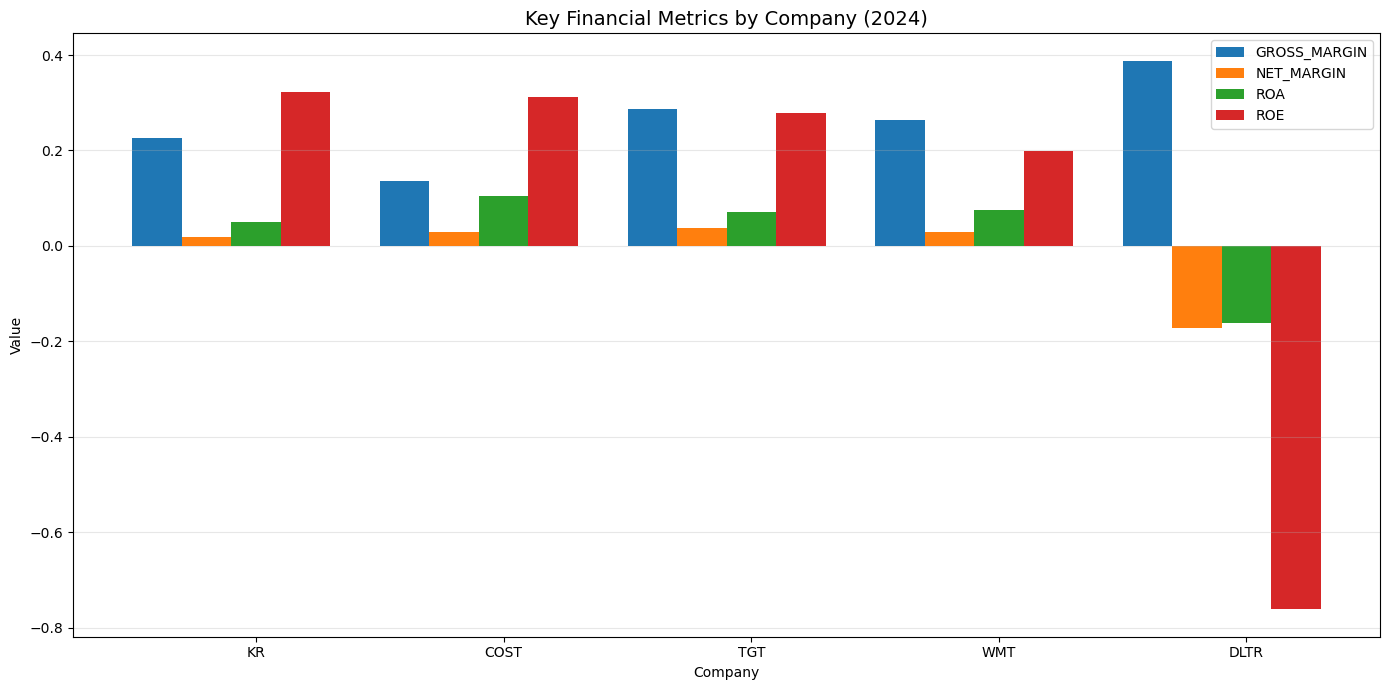

In [8]:
#Bar chart
latest_year = 2024
latest_data = df[df['fyear'] == latest_year].sort_values('roe', ascending=False)

metrics = ['gross_margin', 'net_margin', 'roa', 'roe']
x = range(len(latest_data['tic']))
width = 0.2

fig, ax = plt.subplots(figsize=(14, 7))

for i, metric in enumerate(metrics):
    values = latest_data[metric].values
    offset = (i - len(metrics)/2) * width
    ax.bar([xi + offset for xi in x], values, width, label=metric.upper())

ax.set_xlabel('Company')
ax.set_ylabel('Value')
ax.set_title(f'Key Financial Metrics by Company ({latest_year})', fontsize=14)
ax.set_xticks(x)
ax.set_xticklabels(latest_data['tic'])
ax.legend()
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('metrics_bar_chart.png', dpi=150)
plt.show()

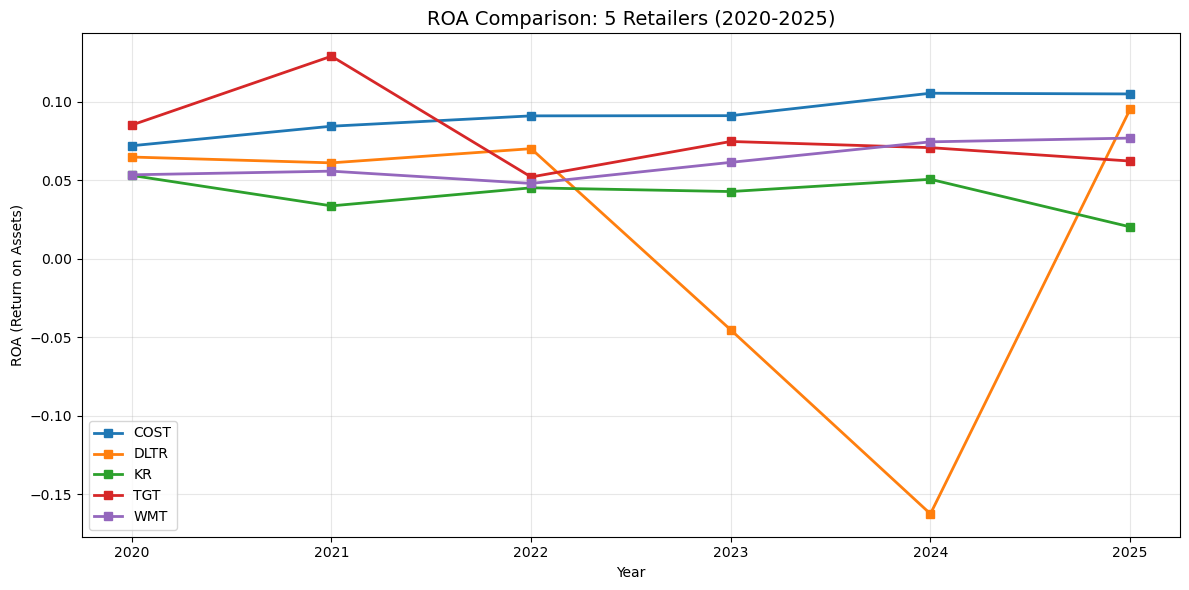

In [13]:
#ROA trend
plt.figure(figsize=(12, 6))

for company in df['tic'].unique():
    company_data = df[df['tic'] == company]
    plt.plot(company_data['fyear'], company_data['roa'], 
             's-', linewidth=2, markersize=6, label=company)

plt.title('ROA Comparison: 5 Retailers (2020-2025)', fontsize=14)
plt.xlabel('Year')
plt.ylabel('ROA (Return on Assets)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('roa_line.png', dpi=150)
plt.show()

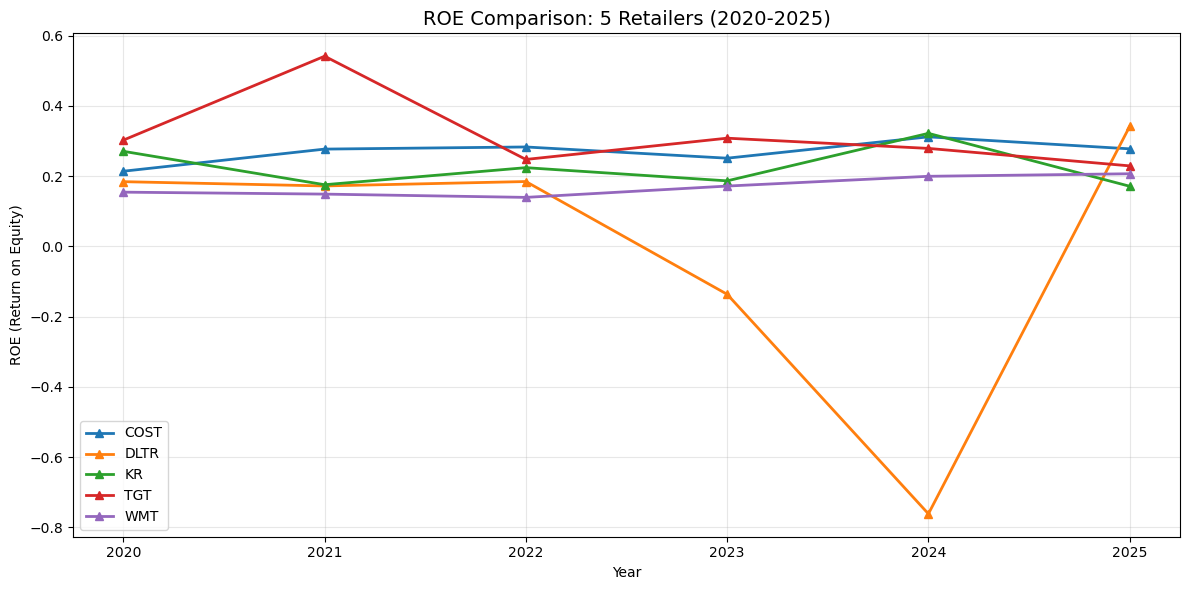

In [14]:
#ROE trend
plt.figure(figsize=(12, 6))

for company in df['tic'].unique():
    company_data = df[df['tic'] == company]
    plt.plot(company_data['fyear'], company_data['roe'], 
             '^-', linewidth=2, markersize=6, label=company)

plt.title('ROE Comparison: 5 Retailers (2020-2025)', fontsize=14)
plt.xlabel('Year')
plt.ylabel('ROE (Return on Equity)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('roe_line.png', dpi=150)
plt.show()

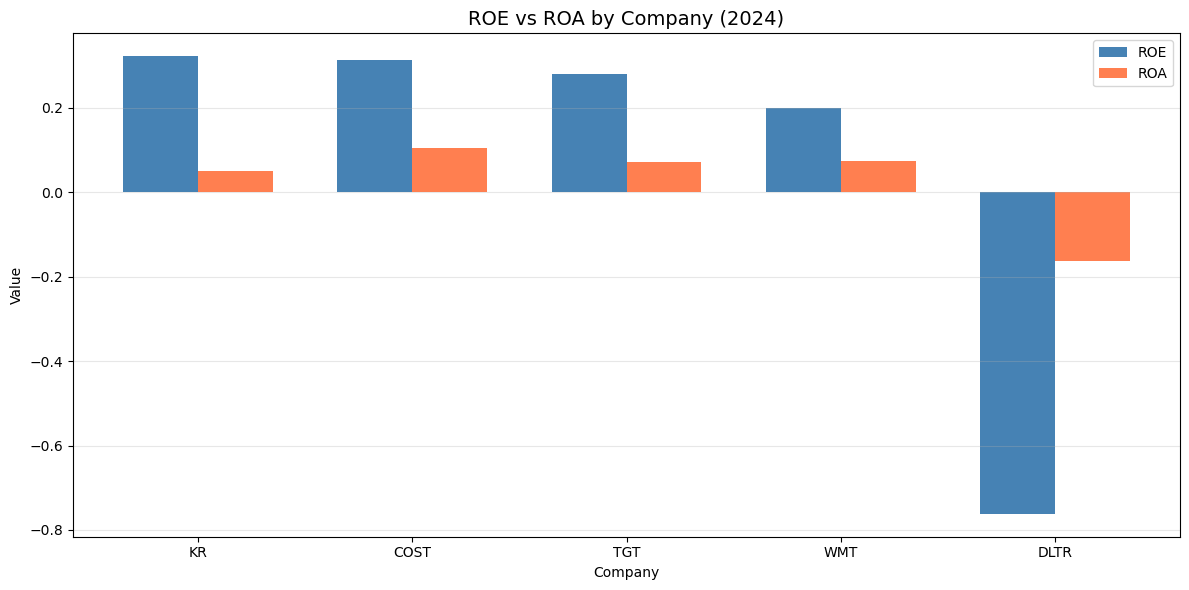

In [15]:
#ROE ROA comparision
latest_year = 2024
latest_data = df[df['fyear'] == latest_year].sort_values('roe', ascending=False)

plt.figure(figsize=(12, 6))
x = range(len(latest_data))
width = 0.35

plt.bar([i - width/2 for i in x], latest_data['roe'], width, label='ROE', color='steelblue')
plt.bar([i + width/2 for i in x], latest_data['roa'], width, label='ROA', color='coral')

plt.xlabel('Company')
plt.ylabel('Value')
plt.title(f'ROE vs ROA by Company ({latest_year})', fontsize=14)
plt.xticks(x, latest_data['tic'])
plt.legend()
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig('roe_roa_bar.png', dpi=150)
plt.show()

In [5]:
stock_clean = stock_data.dropna(subset=['ret']).copy()
stock_clean['date'] = pd.to_datetime(stock_clean['date'])
stock_clean = stock_clean.sort_values(['ticker', 'date'])

stock_clean['cumulative_return'] = stock_clean.groupby('ticker')['ret'].transform(
    lambda x: (1 + x).cumprod() - 1
)

print("Monthly data count per company:")
print(stock_clean['ticker'].value_counts())

# Save cleaned stock data
stock_clean.to_csv('five_retailers_stock_clean.csv', index=False)
print("\nStock data saved to five_retailers_stock_clean.csv")

Monthly data count per company:
ticker
COST    60
DLTR    60
KR      60
TGT     60
WMT     60
Name: count, dtype: Int64

Stock data saved to five_retailers_stock_clean.csv


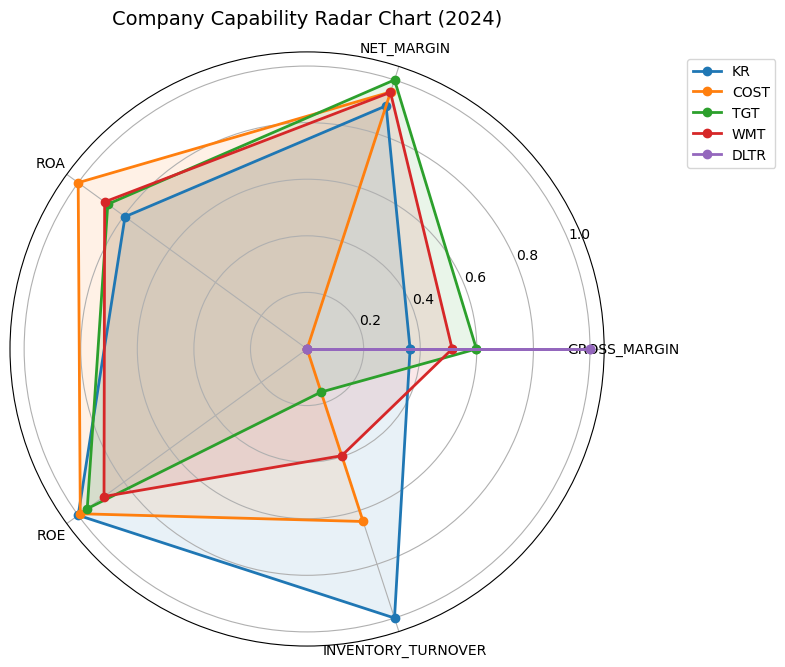

In [12]:
import numpy as np

#Normalization function
def normalize(series):
    return (series - series.min()) / (series.max() - series.min())

latest_norm = latest_data.copy()
metrics_radar = ['gross_margin', 'net_margin', 'roa', 'roe', 'inventory_turnover']
for m in metrics_radar:
    latest_norm[m + '_norm'] = normalize(latest_norm[m])

#Radar chart
angles = np.linspace(0, 2 * np.pi, len(metrics_radar), endpoint=False).tolist()
angles += angles[:1]  # 闭合

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))

for _, row in latest_norm.iterrows():
    values = [row[m + '_norm'] for m in metrics_radar]
    values += values[:1]
    ax.plot(angles, values, 'o-', linewidth=2, label=row['tic'])
    ax.fill(angles, values, alpha=0.1)

ax.set_xticks(angles[:-1])
ax.set_xticklabels([m.upper() for m in metrics_radar])
ax.set_title(f'Company Capability Radar Chart ({latest_year})', fontsize=14, pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.0))
plt.tight_layout()
plt.savefig('radar_chart.png', dpi=150)
plt.show()

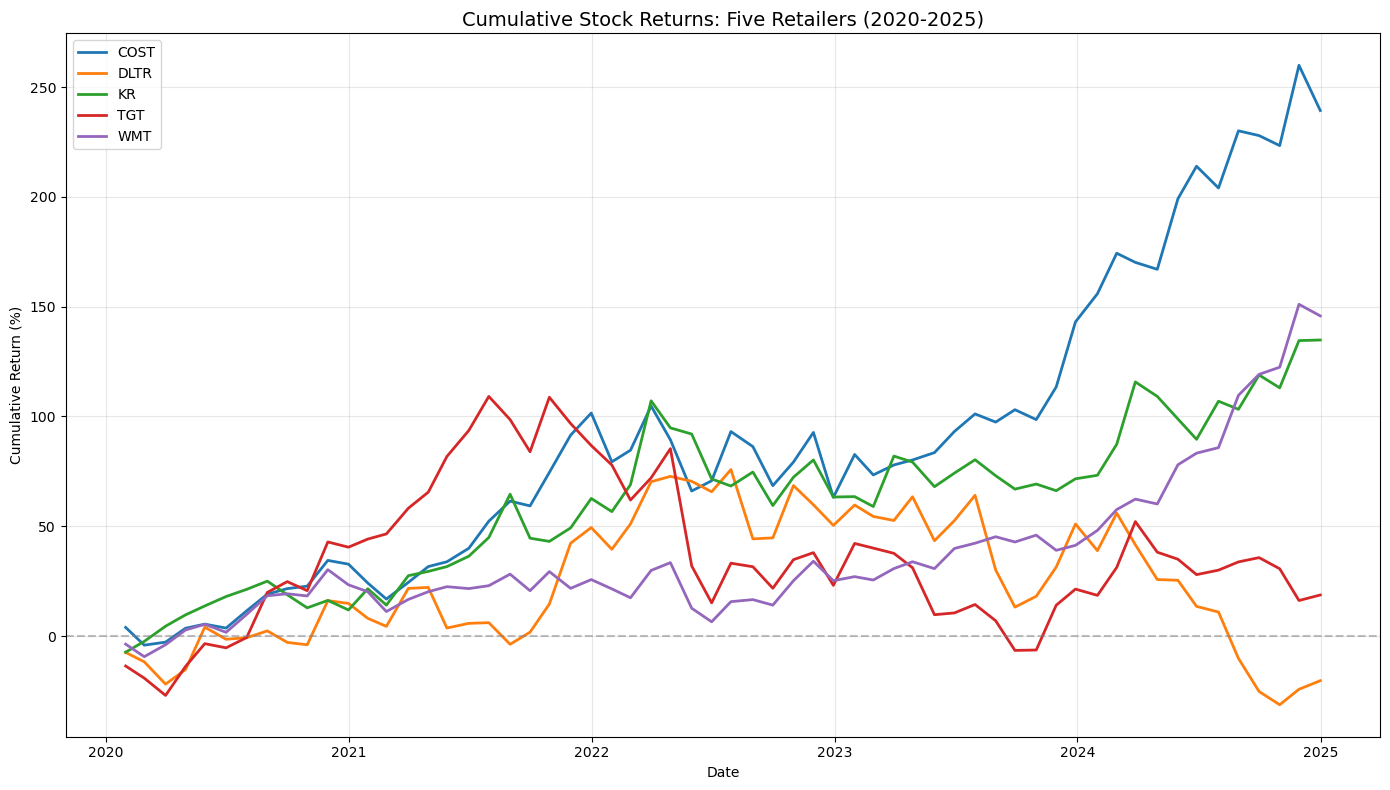

Chart saved as five_retailers_returns.png


In [6]:
#Draw a comparison chart of cumulative returns of five companies
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 8))

for ticker in stock_clean['ticker'].unique():
    subset = stock_clean[stock_clean['ticker'] == ticker]
    plt.plot(subset['date'], subset['cumulative_return'] * 100, linewidth=2, label=ticker)

plt.title('Cumulative Stock Returns: Five Retailers (2020-2025)', fontsize=14)
plt.xlabel('Date')
plt.ylabel('Cumulative Return (%)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.axhline(y=0, color='gray', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig('five_retailers_returns.png', dpi=150)
plt.show()
print("Chart saved as five_retailers_returns.png")

In [17]:
# ROE Volatility 
roe_volatility = df.groupby('tic')['roe'].std().sort_values()
gm_volatility = df.groupby('tic')['gross_margin'].std().sort_values()

print("=" * 50)
print("ROE Volatility (Lower = More Stable)")
print("=" * 50)
print(roe_volatility.round(4))

print("\n" + "=" * 50)
print("Gross Margin Volatility (Lower = More Stable)")
print("=" * 50)
print(gm_volatility.round(4))

ROE Volatility (Lower = More Stable)
tic
WMT     0.0278
COST    0.0332
KR      0.0605
TGT     0.1137
DLTR    0.4033
Name: roe, dtype: Float64

Gross Margin Volatility (Lower = More Stable)
tic
COST    0.0043
WMT     0.0044
KR      0.0075
TGT     0.0175
DLTR    0.0319
Name: gross_margin, dtype: Float64


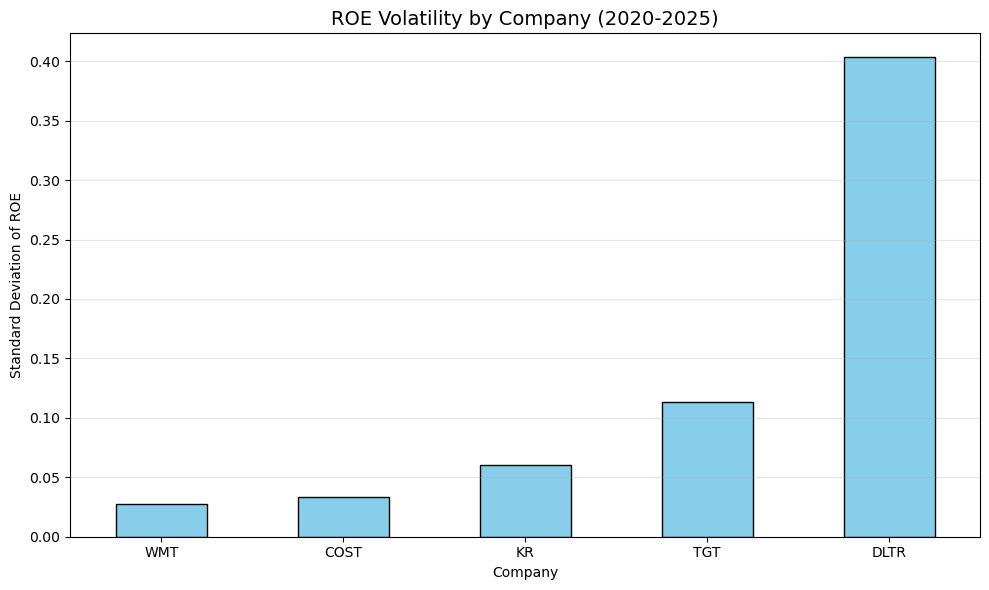

In [18]:
#Draw a volatility bar chart
plt.figure(figsize=(10, 6))
roe_volatility.plot(kind='bar', color='skyblue', edgecolor='black')
plt.title('ROE Volatility by Company (2020-2025)', fontsize=14)
plt.xlabel('Company')
plt.ylabel('Standard Deviation of ROE')
plt.xticks(rotation=0)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('roe_volatility.png', dpi=150)
plt.show()

In [19]:
#Calculate industry average by year (average of five companies)
industry_avg_roe = df.groupby('fyear')['roe'].mean().reset_index()
industry_avg_roe.columns = ['fyear', 'industry_avg_roe']

industry_avg_gm = df.groupby('fyear')['gross_margin'].mean().reset_index()
industry_avg_gm.columns = ['fyear', 'industry_avg_gm']

print("Industry Average ROE by Year:")
print(industry_avg_roe)

Industry Average ROE by Year:
   fyear  industry_avg_roe
0   2020          0.225133
1   2021          0.262968
2   2022          0.215736
3   2023          0.156172
4   2024          0.070062
5   2025          0.245275


Data loaded successfully
    tic  fyear      sale      cogs      ni       at     invt      teq  \
0  COST   2020  166761.0  143186.0  4002.0  55556.0  12242.0  18705.0   
1  COST   2021  195929.0  168903.0  5007.0  59268.0  14215.0  18078.0   
2  COST   2022  226954.0  197482.0  5844.0  64166.0  17907.0  20647.0   
3  COST   2023  242290.0  210509.0  6292.0  68994.0  16651.0  25058.0   
4  COST   2024  254453.0  220121.0  7367.0  69831.0  18647.0  23622.0   

   gross_margin  net_margin       roa       roe  inventory_turnover  
0      0.141370    0.023998  0.072035  0.213953           11.696291  
1      0.137938    0.025555  0.084481  0.276966           11.882026  
2      0.129859    0.025750  0.091076  0.283044           11.028201  
3      0.131169    0.025969  0.091196  0.251097           12.642424  
4      0.134925    0.028952  0.105498  0.311870           11.804633  

Column names:
['tic', 'fyear', 'sale', 'cogs', 'ni', 'at', 'invt', 'teq', 'gross_margin', 'net_margin', 'roa', 'roe

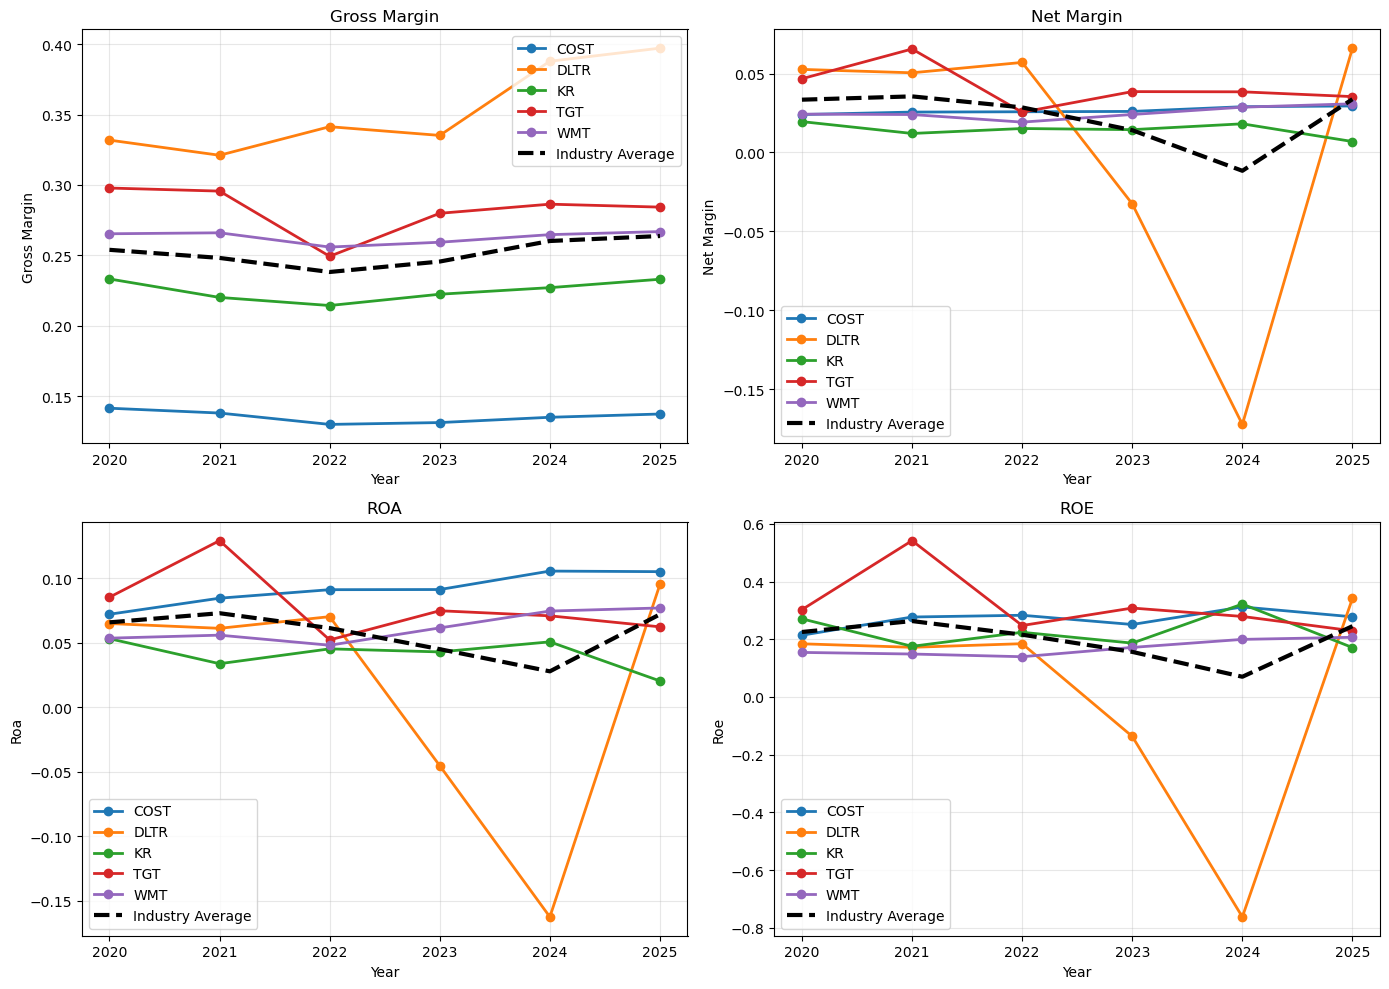

Chart should now be displayed


In [4]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('data/five_retailers_ratios.csv')

print("Data loaded successfully")
print(df.head())
print("\nColumn names:")
print(df.columns.tolist())
print("\nCompany list:")
print(df['tic'].unique())

filtered_df = df[df['tic'].isin(['WMT', 'TGT', 'COST', 'KR', 'DLTR'])]

metrics4 = ['gross_margin', 'net_margin', 'roa', 'roe']
titles4 = ['Gross Margin', 'Net Margin', 'ROA', 'ROE']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
industry_avg_all = filtered_df.groupby('fyear')[metrics4].mean()

for i, (metric, title) in enumerate(zip(metrics4, titles4)):
    ax = axes[i // 2, i % 2]
    for company in filtered_df['tic'].unique():
        company_data = filtered_df[filtered_df['tic'] == company]
        ax.plot(company_data['fyear'], company_data[metric], 'o-', linewidth=2, markersize=6, label=company)
    ax.plot(industry_avg_all.index, industry_avg_all[metric], 'k--', linewidth=3, label='Industry Average')
    ax.set_title(title, fontsize=12)
    ax.set_xlabel('Year')
    ax.set_ylabel(metric.replace('_', ' ').title())
    ax.legend(loc='best')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("Chart should now be displayed")

In [23]:
#Retrieve the latest year's data (2024 or 2025)
latest_year = df['fyear'].max()
latest = df[df['fyear'] == latest_year].copy()

from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()

#Select rating indicators: profitability (ROE, net profit margin), efficiency (inventory turnover rate), stability (ROE volatility)
#Attention: The lower the volatility, the better. Reverse normalization is required
metrics_score = ['roe', 'net_margin', 'inventory_turnover']
score_df = latest[['tic'] + metrics_score].copy()

for m in metrics_score:
    score_df[m + '_score'] = scaler.fit_transform(score_df[[m]]) * 100

# caliculate total
score_df['total_score'] = score_df[[m + '_score' for m in metrics_score]].mean(axis=1)
score_df = score_df.sort_values('total_score', ascending=False)

print("=" * 60)
print(f"Comprehensive Scorecard (Based on {latest_year} Data)")
print("=" * 60)
print(score_df[['tic', 'roe', 'net_margin', 'inventory_turnover', 'total_score']].round(2))

Comprehensive Scorecard (Based on 2025 Data)
     tic   roe  net_margin  inventory_turnover  total_score
11  DLTR  0.34        0.07                4.69        66.67
5   COST  0.28        0.03               13.11        57.44
17    KR  0.17        0.01               16.43        33.33
29   WMT  0.21        0.03                8.85        32.26
23   TGT  0.23        0.04                 6.1        31.38


In [6]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('data/five_retailers_ratios.csv')
print("Data loaded")

roe_volatility = df.groupby('tic')['roe'].std().sort_values()
print("ROE Volatility:")
print(roe_volatility)

trend_roe = df.groupby('fyear')['roe'].mean()
if trend_roe.iloc[-1] > trend_roe.iloc[0]:
    trend_msg = "The overall ROE of the industry is showing an upward trend."
else:
    trend_msg = "The overall ROE of the industry is showing a downward trend."

most_stable = roe_volatility.idxmin()
most_profitable = df.groupby('tic')['roe'].mean().idxmax()

insight_text = f"""
Industry Insights (2020-2025)

{trend_msg}
Most stable company: {most_stable} (lowest ROE volatility)
Most profitable company: {most_profitable} (highest average ROE)
Costco and Walmart showed stronger resilience during inflation periods.
Investment implication: For growth, consider {most_profitable}; for safety, consider {most_stable}.
"""

print(insight_text)


Data loaded
ROE Volatility:
tic
WMT     0.027756
COST    0.033241
KR      0.060479
TGT     0.113735
DLTR    0.403295
Name: roe, dtype: float64

Industry Insights (2020-2025)

The overall ROE of the industry is showing an upward trend.
Most stable company: WMT (lowest ROE volatility)
Most profitable company: TGT (highest average ROE)
Costco and Walmart showed stronger resilience during inflation periods.
Investment implication: For growth, consider TGT; for safety, consider WMT.



In [24]:
import os
print(os.getcwd())

/Users/zhouyiran
